# 02 — The Post-Quantum Defense: ML-KEM Performance Analysis

**Goal**: Evaluate ML-KEM (Module-Lattice-Based Key Encapsulation Mechanism) as a practical defense against the quantum threat demonstrated in Notebook 01.

While Shor's algorithm threatens RSA and elliptic-curve cryptography, the cryptographic community has not been idle. NIST standardized **ML-KEM** (FIPS 203, formerly CRYSTALS-Kyber) as the primary post-quantum key encapsulation mechanism in August 2024. This notebook explores:

1. How ML-KEM works at the API level (keygen, encapsulate, decapsulate)
2. The three parameter sets (ML-KEM-512, 768, 1024) and their security/performance tradeoffs
3. Benchmark results comparing ML-KEM against the classical X25519 (Curve25519 ECDH)
4. Key and ciphertext size analysis — the real cost of post-quantum migration
5. Statistical analysis of timing distributions

**Key finding**: ML-KEM is computationally *faster* than X25519 on modern hardware, making the performance argument for migration compelling. The real cost is larger key and ciphertext sizes (~1 KB vs 32 bytes).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import oqs
from pathlib import Path

# Consistent styling across the notebook
sns.set_style('whitegrid')

# Ensure output directory exists
figures_dir = Path('../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"liboqs version: {oqs.oqs_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("Setup OK")

liboqs version: 0.15.0
NumPy: 2.4.4
Pandas: 3.0.2
Setup OK


/Users/utkarsh.c/btech-pqc-shors/.venv/lib/python3.14/site-packages/oqs/__init__.py:1: UserWarning: liboqs version (major, minor) 0.15.0 differs from liboqs-python version 0.14.1
  from oqs.oqs import (


## 1. ML-KEM Hello World

**ML-KEM** (Module-Lattice-Based Key Encapsulation Mechanism) is standardized as [NIST FIPS 203](https://csrc.nist.gov/pubs/fips/203/final). It was formerly known as CRYSTALS-Kyber.

A **KEM** (Key Encapsulation Mechanism) is a three-step protocol:

1. **KeyGen**: Alice generates a public/secret key pair
2. **Encapsulate**: Bob uses Alice's public key to produce a *ciphertext* and a *shared secret*
3. **Decapsulate**: Alice uses her secret key + the ciphertext to recover the *same* shared secret

After this exchange, both parties share a 32-byte secret that can be used as a symmetric key (e.g., for AES-256-GCM). The security relies on the hardness of the **Module Learning With Errors (MLWE)** problem, which is believed to resist both classical and quantum attacks.

Let's see it in action with ML-KEM-768 (the recommended security level, roughly equivalent to AES-192).

In [2]:
# ML-KEM-768 Hello World: keygen -> encapsulate -> decapsulate
kem = oqs.KeyEncapsulation("ML-KEM-768")
public_key = kem.generate_keypair()
ciphertext, shared_secret_enc = kem.encap_secret(public_key)
shared_secret_dec = kem.decap_secret(ciphertext)

assert shared_secret_enc == shared_secret_dec

print("ML-KEM-768 Key Exchange")
print("=" * 40)
print(f"Public key:    {len(public_key)} bytes")
print(f"Secret key:    {kem.details['length_secret_key']} bytes")
print(f"Ciphertext:    {len(ciphertext)} bytes")
print(f"Shared secret: {len(shared_secret_enc)} bytes")
print(f"")
print(f"Secrets match: {shared_secret_enc == shared_secret_dec}")
print(f"")
print(f"Shared secret (hex): {shared_secret_enc.hex()[:64]}...")

ML-KEM-768 Key Exchange
Public key:    1184 bytes
Secret key:    2400 bytes
Ciphertext:    1088 bytes
Shared secret: 32 bytes

Secrets match: True

Shared secret (hex): df1d116cb2cd649607f4427b6d5cc764ebd91bf274b48eeba21db6726574ac9c...


## 2. All ML-KEM Parameter Sets

ML-KEM comes in three parameter sets, trading security for size/speed:

| Parameter Set | NIST Level | Classical Equivalent | Module Rank |
|--------------|------------|---------------------|-------------|
| ML-KEM-512   | 1          | AES-128             | k=2         |
| ML-KEM-768   | 3          | AES-192             | k=3         |
| ML-KEM-1024  | 5          | AES-256             | k=4         |

All three produce a 32-byte shared secret. The differences are in key/ciphertext sizes and computational cost. Let's exercise each one.

In [3]:
# Exercise all three ML-KEM parameter sets
variants = ["ML-KEM-512", "ML-KEM-768", "ML-KEM-1024"]
rows = []

for name in variants:
    kem = oqs.KeyEncapsulation(name)
    pk = kem.generate_keypair()
    ct, ss_enc = kem.encap_secret(pk)
    ss_dec = kem.decap_secret(ct)
    
    assert ss_enc == ss_dec, f"{name}: shared secrets do not match!"
    
    rows.append({
        'Algorithm': name,
        'Public Key (bytes)': len(pk),
        'Secret Key (bytes)': kem.details['length_secret_key'],
        'Ciphertext (bytes)': len(ct),
        'Shared Secret (bytes)': len(ss_enc),
        'Secrets Match': ss_enc == ss_dec,
    })
    
    print(f"{name}: keygen OK, encap OK, decap OK, secrets match")

print("\n--- Size Comparison ---")
df_sizes_live = pd.DataFrame(rows)
print(df_sizes_live.to_string(index=False))

ML-KEM-512: keygen OK, encap OK, decap OK, secrets match
ML-KEM-768: keygen OK, encap OK, decap OK, secrets match
ML-KEM-1024: keygen OK, encap OK, decap OK, secrets match

--- Size Comparison ---
  Algorithm  Public Key (bytes)  Secret Key (bytes)  Ciphertext (bytes)  Shared Secret (bytes)  Secrets Match
 ML-KEM-512                 800                1632                 768                     32           True
 ML-KEM-768                1184                2400                1088                     32           True
ML-KEM-1024                1568                3168                1568                     32           True


## 3. Benchmark Results

We benchmarked all three ML-KEM parameter sets and X25519 (Curve25519 ECDH) using 10,000 iterations per operation. Timing uses `time.perf_counter_ns()` for nanosecond precision.

The benchmark script (`src/benchmarks/bench_mlkem.py`) performs:
- **KeyGen**: Generate a fresh key pair
- **Encapsulate**: Produce ciphertext + shared secret from a public key
- **Decapsulate**: Recover shared secret from ciphertext + secret key

Results are stored in `results/raw/` as CSV files.

In [4]:
# Load and display summary statistics
try:
    mlkem_summary = pd.read_csv('../results/raw/mlkem_summary.csv')
    x25519_summary = pd.read_csv('../results/raw/x25519_summary.csv')
    
    print("ML-KEM Benchmark Summary (microseconds)")
    print("=" * 80)
    display_cols = ['algorithm', 'operation', 'mean_us', 'median_us', 'std_us', 'p95_us', 'min_us', 'max_us']
    print(mlkem_summary[display_cols].to_string(index=False))
    
    print("\n")
    print("X25519 (Classical) Benchmark Summary (microseconds)")
    print("=" * 80)
    print(x25519_summary[display_cols].to_string(index=False))
    
except FileNotFoundError:
    print("Benchmark data not found!")
    print("Run `make mlkem-bench` first to generate the benchmark data.")

ML-KEM Benchmark Summary (microseconds)
  algorithm   operation   mean_us  median_us    std_us   p95_us  min_us   max_us
ML-KEM-1024 decapsulate 16.730296     16.833  0.760483 17.25000  15.000   29.083
ML-KEM-1024 encapsulate 15.151500     15.167  0.822552 15.58300  13.333   36.334
ML-KEM-1024      keygen 13.884549     13.916  2.852620 14.62500  12.042  287.292
 ML-KEM-512 decapsulate  7.630740      7.708  0.640036  7.95900   6.708   35.792
 ML-KEM-512 encapsulate  7.606115      7.333 28.999693  8.21105   6.416 2905.167
 ML-KEM-512      keygen  6.158744      6.166  5.195750  6.83400   5.458  511.292
 ML-KEM-768 decapsulate 11.609036     11.583  0.664873 12.45800  10.166   22.750
 ML-KEM-768 encapsulate 11.118260     11.291  1.091933 11.58300   9.750   52.583
 ML-KEM-768      keygen  9.771987      9.625 10.624321 10.37500   8.375 1069.791


X25519 (Classical) Benchmark Summary (microseconds)
algorithm   operation    mean_us  median_us     std_us    p95_us  min_us    max_us
   X25519 dec

In [5]:
# Load and display size comparison
try:
    mlkem_sizes = pd.read_csv('../results/raw/mlkem_sizes.csv')
    x25519_sizes = pd.read_csv('../results/raw/x25519_sizes.csv')
    
    all_sizes = pd.concat([mlkem_sizes, x25519_sizes], ignore_index=True)
    
    print("Key and Ciphertext Sizes (bytes)")
    print("=" * 70)
    print(all_sizes.to_string(index=False))
    
    print("\nSize ratios vs X25519:")
    x25519_pk = x25519_sizes['public_key_bytes'].iloc[0]
    for _, row in mlkem_sizes.iterrows():
        ratio = row['public_key_bytes'] / x25519_pk
        print(f"  {row['algorithm']} public key is {ratio:.0f}x larger than X25519")

except FileNotFoundError:
    print("Size data not found!")
    print("Run `make mlkem-bench` first to generate the benchmark data.")

Key and Ciphertext Sizes (bytes)
  algorithm  public_key_bytes  secret_key_bytes  ciphertext_bytes  shared_secret_bytes
 ML-KEM-512               800              1632               768                   32
 ML-KEM-768              1184              2400              1088                   32
ML-KEM-1024              1568              3168              1568                   32
     X25519                32                32                32                   32

Size ratios vs X25519:
  ML-KEM-512 public key is 25x larger than X25519
  ML-KEM-768 public key is 37x larger than X25519
  ML-KEM-1024 public key is 49x larger than X25519


## 4. Performance Comparison: ML-KEM vs X25519

The central question for migration: **how much slower is ML-KEM compared to the classical algorithms it replaces?**

Spoiler: ML-KEM is actually *faster* on modern hardware. The lattice-based operations (polynomial multiplication over small moduli) are highly efficient and benefit from vectorized instructions (AVX2, NEON). X25519 requires expensive scalar multiplication on an elliptic curve.

/var/folders/qd/h8cnhfhx1qv38sm77sfwkbp00000gp/T/ipykernel_29237/1758601088.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=keygen_data, x='algorithm', y='time_us', order=order, ax=ax2,


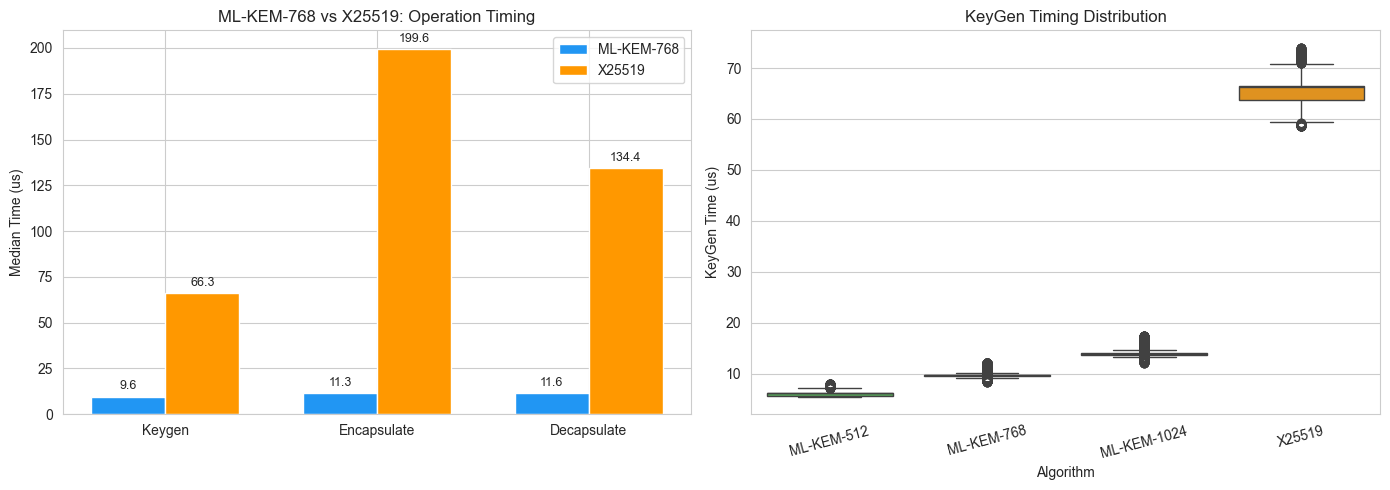

Figure saved to results/figures/mlkem_vs_x25519.png


In [6]:
# Load raw benchmark data for comparison plots
try:
    mlkem_raw = pd.read_csv('../results/raw/mlkem_benchmark.csv')
    x25519_raw = pd.read_csv('../results/raw/x25519_benchmark.csv')
    
    # Convert ns to us
    mlkem_raw['time_us'] = mlkem_raw['time_ns'] / 1000
    x25519_raw['time_us'] = x25519_raw['time_ns'] / 1000
    
    # Combine for analysis
    all_raw = pd.concat([mlkem_raw, x25519_raw], ignore_index=True)
    
    # --- Bar chart: ML-KEM-768 vs X25519 median timing ---
    mlkem_summary = pd.read_csv('../results/raw/mlkem_summary.csv')
    x25519_summary = pd.read_csv('../results/raw/x25519_summary.csv')
    all_summary = pd.concat([mlkem_summary, x25519_summary], ignore_index=True)
    
    # Filter to ML-KEM-768 and X25519 for head-to-head
    compare = all_summary[all_summary['algorithm'].isin(['ML-KEM-768', 'X25519'])].copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: median timings
    operations = ['keygen', 'encapsulate', 'decapsulate']
    x_pos = np.arange(len(operations))
    width = 0.35
    
    mlkem768 = compare[compare['algorithm'] == 'ML-KEM-768']
    x25519 = compare[compare['algorithm'] == 'X25519']
    
    mlkem_vals = [mlkem768[mlkem768['operation'] == op]['median_us'].values[0] for op in operations]
    x25519_vals = [x25519[x25519['operation'] == op]['median_us'].values[0] for op in operations]
    
    bars1 = ax1.bar(x_pos - width/2, mlkem_vals, width, label='ML-KEM-768', color='#2196F3')
    bars2 = ax1.bar(x_pos + width/2, x25519_vals, width, label='X25519', color='#FF9800')
    
    ax1.set_ylabel('Median Time (us)')
    ax1.set_title('ML-KEM-768 vs X25519: Operation Timing')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([op.capitalize() for op in operations])
    ax1.legend()
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)
    
    # Box plot: distribution of timings for all algorithms
    # Filter out first iteration (cold start) and extreme outliers for cleaner vis
    filtered = all_raw[all_raw['iteration'] > 0].copy()
    # Cap at p99 for visualization
    for algo in filtered['algorithm'].unique():
        for op in filtered['operation'].unique():
            mask = (filtered['algorithm'] == algo) & (filtered['operation'] == op)
            subset = filtered.loc[mask, 'time_us']
            if len(subset) > 0:
                p99 = subset.quantile(0.99)
                filtered.loc[mask & (filtered['time_us'] > p99), 'time_us'] = np.nan
    
    filtered = filtered.dropna(subset=['time_us'])
    
    # Only keygen for box plot to keep it readable
    keygen_data = filtered[filtered['operation'] == 'keygen']
    order = ['ML-KEM-512', 'ML-KEM-768', 'ML-KEM-1024', 'X25519']
    sns.boxplot(data=keygen_data, x='algorithm', y='time_us', order=order, ax=ax2,
                palette=['#4CAF50', '#2196F3', '#9C27B0', '#FF9800'])
    ax2.set_xlabel('Algorithm')
    ax2.set_ylabel('KeyGen Time (us)')
    ax2.set_title('KeyGen Timing Distribution')
    ax2.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    fig.savefig('../results/figures/mlkem_vs_x25519.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved to results/figures/mlkem_vs_x25519.png")

except FileNotFoundError as e:
    print(f"Data not found: {e}")
    print("Run `make mlkem-bench` first to generate the benchmark data.")

In [7]:
# Compute and display speedup ratios: how much faster is ML-KEM vs X25519?
try:
    mlkem_summary = pd.read_csv('../results/raw/mlkem_summary.csv')
    x25519_summary = pd.read_csv('../results/raw/x25519_summary.csv')
    
    print("Speedup Ratios: X25519 / ML-KEM (higher = ML-KEM is faster)")
    print("=" * 65)
    
    operations = ['keygen', 'encapsulate', 'decapsulate']
    rows = []
    
    for op in operations:
        x_time = x25519_summary[x25519_summary['operation'] == op]['median_us'].values[0]
        for _, row in mlkem_summary[mlkem_summary['operation'] == op].iterrows():
            m_time = row['median_us']
            speedup = x_time / m_time
            rows.append({
                'Operation': op.capitalize(),
                'Algorithm': row['algorithm'],
                'ML-KEM (us)': f"{m_time:.2f}",
                'X25519 (us)': f"{x_time:.2f}",
                'Speedup': f"{speedup:.1f}x",
            })
    
    speedup_df = pd.DataFrame(rows)
    print(speedup_df.to_string(index=False))
    
    print("\nInterpretation:")
    print("  A speedup > 1.0x means ML-KEM is FASTER than X25519.")
    print("  ML-KEM's lattice arithmetic is highly optimized for modern CPUs.")
    print("  X25519 requires expensive elliptic curve scalar multiplication.")

except FileNotFoundError:
    print("Run `make mlkem-bench` first.")

Speedup Ratios: X25519 / ML-KEM (higher = ML-KEM is faster)
  Operation   Algorithm ML-KEM (us) X25519 (us) Speedup
     Keygen ML-KEM-1024       13.92       66.33    4.8x
     Keygen  ML-KEM-512        6.17       66.33   10.8x
     Keygen  ML-KEM-768        9.62       66.33    6.9x
Encapsulate ML-KEM-1024       15.17      199.62   13.2x
Encapsulate  ML-KEM-512        7.33      199.62   27.2x
Encapsulate  ML-KEM-768       11.29      199.62   17.7x
Decapsulate ML-KEM-1024       16.83      134.42    8.0x
Decapsulate  ML-KEM-512        7.71      134.42   17.4x
Decapsulate  ML-KEM-768       11.58      134.42   11.6x

Interpretation:
  A speedup > 1.0x means ML-KEM is FASTER than X25519.
  ML-KEM's lattice arithmetic is highly optimized for modern CPUs.
  X25519 requires expensive elliptic curve scalar multiplication.


## 5. Key and Ciphertext Size Analysis

While ML-KEM wins on speed, the trade-off is **size**. Post-quantum keys and ciphertexts are significantly larger than their classical counterparts:

- X25519 public key: 32 bytes
- ML-KEM-768 public key: 1,184 bytes (37x larger)
- ML-KEM-768 ciphertext: 1,088 bytes (34x larger)

This matters for bandwidth-constrained protocols (TLS handshake, IoT, satellite links).

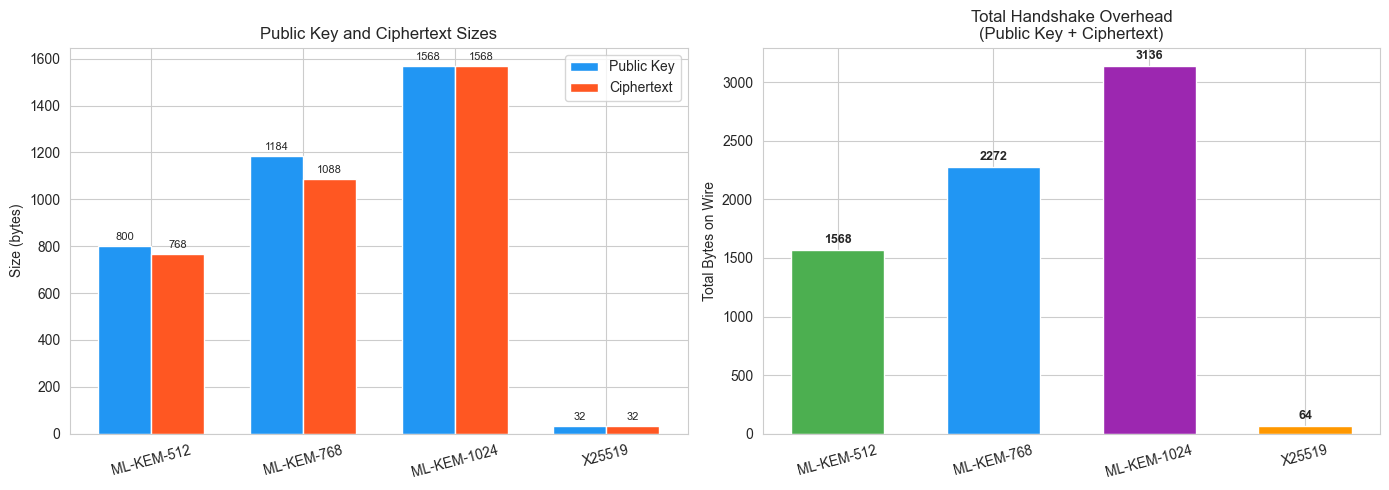

Figure saved to results/figures/size_comparison.png


In [8]:
# Create size comparison bar chart
try:
    mlkem_sizes = pd.read_csv('../results/raw/mlkem_sizes.csv')
    x25519_sizes = pd.read_csv('../results/raw/x25519_sizes.csv')
    all_sizes = pd.concat([mlkem_sizes, x25519_sizes], ignore_index=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    algorithms = all_sizes['algorithm'].tolist()
    x_pos = np.arange(len(algorithms))
    colors = ['#4CAF50', '#2196F3', '#9C27B0', '#FF9800']
    
    # Public key + ciphertext sizes (what goes over the wire)
    pk_sizes = all_sizes['public_key_bytes'].tolist()
    ct_sizes = all_sizes['ciphertext_bytes'].tolist()
    
    width = 0.35
    bars1 = ax1.bar(x_pos - width/2, pk_sizes, width, label='Public Key', color='#2196F3')
    bars2 = ax1.bar(x_pos + width/2, ct_sizes, width, label='Ciphertext', color='#FF5722')
    
    ax1.set_ylabel('Size (bytes)')
    ax1.set_title('Public Key and Ciphertext Sizes')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(algorithms, rotation=15)
    ax1.legend()
    
    # Add value labels
    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        ax1.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)
    
    # Total "wire cost": public key + ciphertext (what a TLS handshake must transmit)
    wire_cost = [pk + ct for pk, ct in zip(pk_sizes, ct_sizes)]
    bars3 = ax2.bar(x_pos, wire_cost, 0.6, color=colors)
    
    ax2.set_ylabel('Total Bytes on Wire')
    ax2.set_title('Total Handshake Overhead\n(Public Key + Ciphertext)')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(algorithms, rotation=15)
    
    for bar in bars3:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    fig.savefig('../results/figures/size_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved to results/figures/size_comparison.png")

except FileNotFoundError:
    print("Run `make mlkem-bench` first.")

## 6. Statistical Distribution Analysis

To understand the *consistency* of ML-KEM performance (important for real-time systems), we look at the full distribution of operation timings rather than just the median.

Key questions:
- Are there outliers or long tails? (Memory allocation, cache effects)
- Is the distribution tight enough for latency-sensitive applications?
- How do the three parameter sets compare in variance?

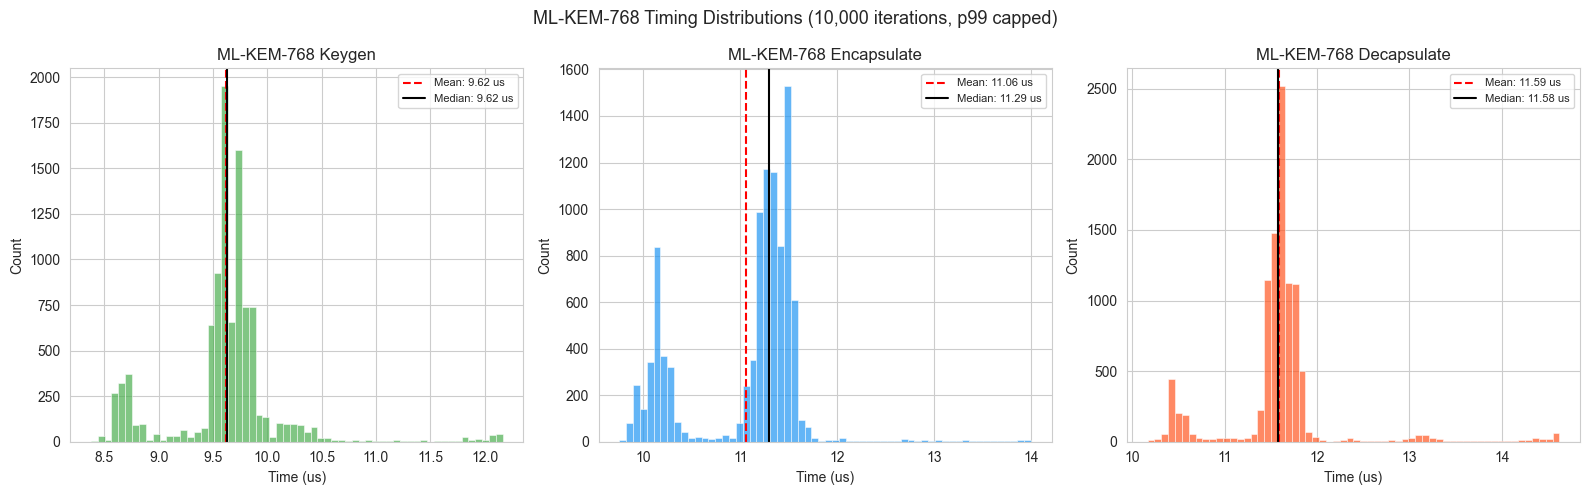

Figure saved to results/figures/timing_distributions.png


/var/folders/qd/h8cnhfhx1qv38sm77sfwkbp00000gp/T/ipykernel_29237/943107968.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=op_data, x='algorithm', y='time_us', order=variant_order,
/var/folders/qd/h8cnhfhx1qv38sm77sfwkbp00000gp/T/ipykernel_29237/943107968.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=op_data, x='algorithm', y='time_us', order=variant_order,
/var/folders/qd/h8cnhfhx1qv38sm77sfwkbp00000gp/T/ipykernel_29237/943107968.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=op_data, x='algorithm',

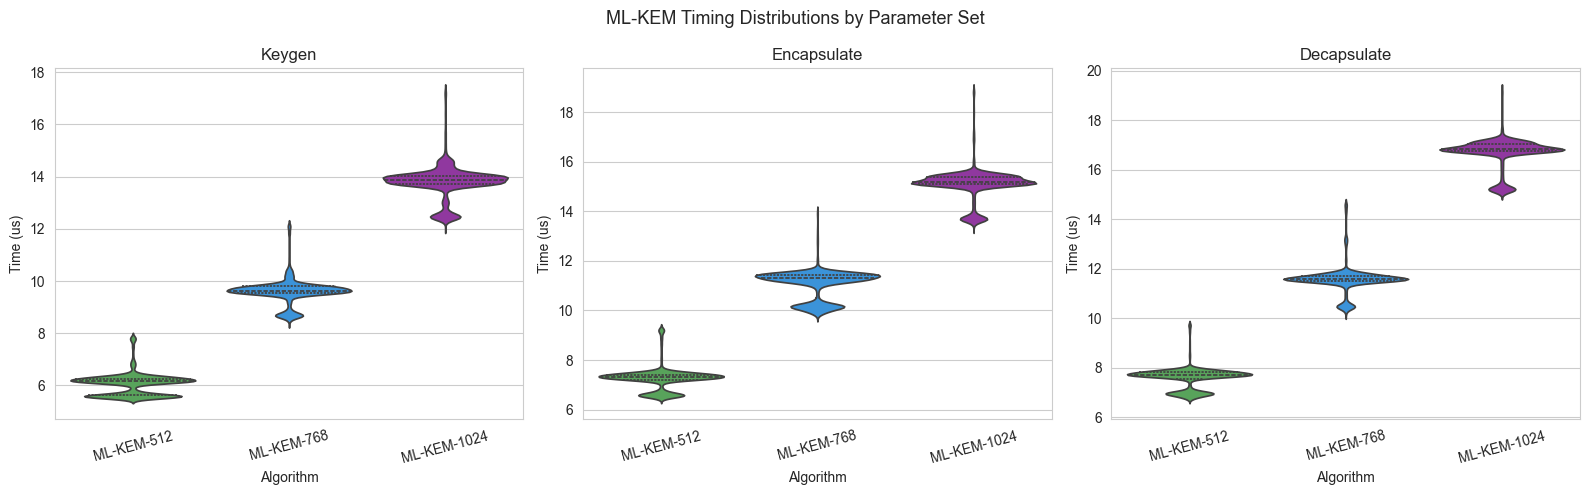

Figure saved to results/figures/mlkem_timing_comparison.png


In [9]:
# Distribution plots for ML-KEM-768 keygen/encap/decap
try:
    mlkem_raw = pd.read_csv('../results/raw/mlkem_benchmark.csv')
    mlkem_raw['time_us'] = mlkem_raw['time_ns'] / 1000
    
    # Focus on ML-KEM-768, skip first iteration (cold start)
    mlkem768 = mlkem_raw[
        (mlkem_raw['algorithm'] == 'ML-KEM-768') & 
        (mlkem_raw['iteration'] > 0)
    ].copy()
    
    # Cap at p99 for cleaner visualization
    for op in mlkem768['operation'].unique():
        mask = mlkem768['operation'] == op
        p99 = mlkem768.loc[mask, 'time_us'].quantile(0.99)
        mlkem768 = mlkem768[~(mask & (mlkem768['time_us'] > p99))]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    operations = ['keygen', 'encapsulate', 'decapsulate']
    op_colors = ['#4CAF50', '#2196F3', '#FF5722']
    
    for ax, op, color in zip(axes, operations, op_colors):
        data = mlkem768[mlkem768['operation'] == op]['time_us']
        
        ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
        
        # Add vertical lines for mean and median
        mean_val = data.mean()
        median_val = data.median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f} us')
        ax.axvline(median_val, color='black', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f} us')
        
        ax.set_xlabel('Time (us)')
        ax.set_ylabel('Count')
        ax.set_title(f'ML-KEM-768 {op.capitalize()}')
        ax.legend(fontsize=8)
    
    plt.suptitle('ML-KEM-768 Timing Distributions (10,000 iterations, p99 capped)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../results/figures/timing_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved to results/figures/timing_distributions.png")
    
    # Also create a violin plot comparing all ML-KEM variants
    mlkem_all = mlkem_raw[mlkem_raw['iteration'] > 0].copy()
    for algo in mlkem_all['algorithm'].unique():
        for op in mlkem_all['operation'].unique():
            mask = (mlkem_all['algorithm'] == algo) & (mlkem_all['operation'] == op)
            p99 = mlkem_all.loc[mask, 'time_us'].quantile(0.99)
            mlkem_all = mlkem_all[~(mask & (mlkem_all['time_us'] > p99))]
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
    variant_order = ['ML-KEM-512', 'ML-KEM-768', 'ML-KEM-1024']
    
    for ax, op in zip(axes2, operations):
        op_data = mlkem_all[mlkem_all['operation'] == op]
        sns.violinplot(data=op_data, x='algorithm', y='time_us', order=variant_order,
                       palette=['#4CAF50', '#2196F3', '#9C27B0'], ax=ax, inner='quartile')
        ax.set_xlabel('Algorithm')
        ax.set_ylabel('Time (us)')
        ax.set_title(f'{op.capitalize()}')
        ax.tick_params(axis='x', rotation=15)
    
    plt.suptitle('ML-KEM Timing Distributions by Parameter Set', fontsize=13)
    plt.tight_layout()
    fig2.savefig('../results/figures/mlkem_timing_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved to results/figures/mlkem_timing_comparison.png")

except FileNotFoundError:
    print("Run `make mlkem-bench` first.")

## 7. Summary and Implications

### Performance

ML-KEM is **computationally fast** — often faster than X25519 on modern hardware. The lattice-based arithmetic (polynomial multiplication modulo small primes) maps efficiently to CPU vector instructions. This demolishes the myth that "post-quantum crypto is slow."

### The Real Cost: Size

The genuine trade-off is **key and ciphertext sizes**:

| Algorithm   | Public Key | Ciphertext | Total Wire Cost |
|-------------|-----------|------------|----------------|
| X25519      | 32 B      | 32 B       | 64 B           |
| ML-KEM-768  | 1,184 B   | 1,088 B    | 2,272 B        |

That is ~35x more data on the wire per key exchange. For a TLS 1.3 handshake, this adds roughly 2 KB — noticeable but manageable for broadband connections, potentially challenging for constrained IoT devices or satellite links.

### Migration Overhead is Manageable

For the vast majority of applications:
- **Latency impact**: negligible (ML-KEM is faster than what it replaces)
- **Bandwidth impact**: ~2 KB extra per handshake — acceptable for most protocols
- **API complexity**: identical KEM interface (keygen/encap/decap) — drop-in replacement at the crypto layer

### Connecting to the Threat

In Notebook 01, we saw that Shor's algorithm can factor integers and break RSA/ECC — though current quantum hardware is far from the scale needed for real keys. However, the **"harvest now, decrypt later"** threat means adversaries may be collecting encrypted traffic today for future quantum decryption.

Given that ML-KEM's migration cost is modest (fast, well-understood, standardized by NIST), there is no reason to wait:

> **The cost of deploying ML-KEM is small. The cost of not deploying it — if a cryptographically relevant quantum computer arrives — is catastrophic.**

Organizations should begin migrating to hybrid key exchange (e.g., X25519 + ML-KEM-768) now, before quantum computers become a practical threat.

---

**Next**: Notebook 03 will integrate both analyses into a unified risk assessment and provide migration recommendations.